In [1]:
import sys
import os
 
# Add project root to Python path
sys.path.append(os.path.abspath(".."))

In [2]:
import pandas as pd

df = pd.read_csv("../data/processed/scaled.csv")
df.head()

,TransactionID,TransactionAmount,TransactionDate,CustomerAge,TransactionDuration,LoginAttempts,AccountBalance,PreviousTransactionDate,TimeSincePrev,AmountBalanceRatio,...,Channel_Branch,Channel_Online,CustomerOccupation_Engineer,CustomerOccupation_Retired,CustomerOccupation_Student,AccountID_freq,DeviceID_freq,IP Address_freq,MerchantID_freq,Location_freq
0,TX000001,-0.971275,2023-04-11 16:29:14,1.423718,-0.552443,-0.206794,-0.000537,2024-11-04 08:08:08,-0.800762,-0.386493,...,False,False,False,False,False,0.394950,0.780834,-1.059021,1.141666,-0.028446
1,TX000002,0.269440,2023-06-27 16:44:19,1.311287,0.305314,-0.206794,2.216472,2024-11-04 08:09:35,-0.076706,-0.338188,...,False,False,False,False,False,0.394950,0.235683,-0.568379,0.168981,0.598373
2,TX000003,-0.586882,2023-07-10 18:16:08,-1.443277,-0.909842,-0.206794,-1.023534,2024-11-04 08:07:04,0.046138,-0.171040,...,False,True,False,False,True,-0.936152,0.235683,0.903547,0.752592,0.284963
3,TX000004,-0.387456,2023-05-05 16:32:11,-1.049768,-1.353017,-0.206794,0.885797,2024-11-04 08:09:06,-0.575097,-0.349611,...,False,True,False,False,True,0.838651,0.780834,1.394189,0.947129,-0.028446
4,TX000005,-0.973468,2023-10-16 17:51:24,-1.049768,1.120184,-0.206794,0.593589,2024-11-04 08:06:39,0.967391,-0.388350,...,False,True,False,False,True,-0.048751,-0.854621,-0.568379,0.947129,0.284963


In [3]:
df = pd.read_csv("../data/processed/scaled.csv")

# Drop non-numeric columns
df = df.drop(columns=[
    "TransactionID",
    "TransactionDate",
    "PreviousTransactionDate"
], errors="ignore")

# Keep only numeric columns
df_numeric = df.select_dtypes(include=["int64", "float64", "bool"])

# Convert bool → int
df_numeric = df_numeric.astype(float)


In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components=0.95)
X_pca = pca.fit_transform(df)

print("Original shape:", df.shape)
print("PCA shape:", X_pca.shape)


Original shape: (2512, 20)
PCA shape: (2512, 14)


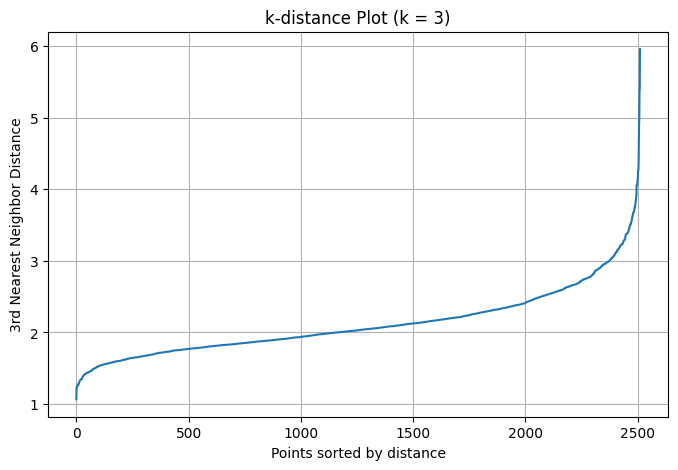

In [17]:
from sklearn.neighbors import NearestNeighbors
import numpy as np
import matplotlib.pyplot as plt

k = 3  # MinPts = 5 → k = MinPts - 1

nn = NearestNeighbors(n_neighbors=k)
nn.fit(X_pca)
distances, _ = nn.kneighbors(X_pca)

k_distances = np.sort(distances[:, -1])

plt.figure(figsize=(8,5))
plt.plot(k_distances)
plt.title("k-distance Plot (k = 3)")
plt.xlabel("Points sorted by distance")
plt.ylabel("3rd Nearest Neighbor Distance")
plt.grid(True)
plt.show()


In [18]:
from src.clustering.dbscan import DBSCANClustering

dbscan = DBSCANClustering(eps=3.5, min_samples=5)
dbscan.fit(X_pca)
dbscan.plot_clusters(X_pca)


[INFO] Plot saved to: ../results/dbscan\dbscan_eps3.5_min5_clusters2.png


In [ ]:
labels = dbscan.labels_

noise_idx = np.where(labels == -1)[0]
border_idx = np.where(labels != -1)[0]

print("Noise points:", len(noise_idx))
print("Cluster labels:", np.unique(labels)) 


Noise points: 32
Cluster labels: [-1  0  1]


In [32]:
import numpy as np
import pandas as pd
from sklearn.neighbors import NearestNeighbors

X = X_pca
labels = dbscan.labels_
eps = dbscan.eps
min_samples = dbscan.min_samples

# Compute neighbors to classify core/border
nn = NearestNeighbors(radius=eps)
nn.fit(X)
neighbors = nn.radius_neighbors(X, return_distance=False)

point_type = []
for i in range(len(X)):
    if labels[i] == -1:
        point_type.append("noise")
    elif len(neighbors[i]) >= min_samples:
        point_type.append("core")
    else:
        point_type.append("border")

df_dbscan = pd.DataFrame({
    "PC1": X[:,0],
    "PC2": X[:,1],
    "cluster": labels,
    "type": point_type
})

df_dbscan.head()



,PC1,PC2,cluster,type
0,0.051517,-1.424682,0,core
1,0.307561,-1.969267,0,core
2,-0.620070,0.693827,0,core
3,-0.368306,-0.235244,0,core
4,-0.169195,-0.408661,0,core


In [38]:
noise_df = df_dbscan[df_dbscan["cluster"] == -1]
noise_df

,PC1,PC2,cluster,type
146,-0.431688,0.011190,-1,noise
224,-0.831329,2.278209,-1,noise
274,6.168693,6.452750,-1,noise
449,-1.916114,5.723946,-1,noise
450,-1.833624,6.677234,-1,noise
476,4.054816,0.967291,-1,noise
564,3.484758,3.253436,-1,noise
588,6.359251,0.009419,-1,noise
619,4.736382,-0.832561,-1,noise
754,5.350931,0.619472,-1,noise


In [33]:
df_dbscan.to_csv("../results/dbscan/dbscan_anomaly_table.csv", index=False)
print("[INFO] Saved DBSCAN anomaly table.")


[INFO] Saved DBSCAN anomaly table.


In [36]:
X_pca.shape

(2512, 14)

## 📌 DBSCAN Anomaly Analysis

DBSCAN identified two dense clusters (0 and 1) and 32 noise points. Noise points represent strong anomalies because they do not belong to any sufficiently dense region. Border points lie on the edge of clusters and represent borderline anomalies, while core points represent stable, high-density behavior.

- **Cluster 0**: Dense, stable region (core-dominated)
- **Cluster 1**: Second dense region with slightly different structure
- **Noise (-1)**: 32 isolated points → strong anomalies
- **Border points**: Transitional behavior between normal and anomalous

This density-based anomaly detection complements KMeans by identifying local irregularities that distance-based methods may miss.
